<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>04 $\rightarrow$ Pedestrian Detection in Video Streams</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Full-Body Silhouette Localization & Flow Analytics in Video Streams)</span>
</div>

---

## Overview
In this notebook, we detect **Walking Pedestrians** in video streams using OpenCV and the pre-trained `haarcascade_fullbody.xml` model.

### Key Concepts Covered:
1. Loading and inspecting video streams with `cv2.VideoCapture`.
2. Extracting technical video properties (Resolution, FPS, Total Frames, Duration).
3. Detecting full-body silhouettes across video frames with `detectMultiScale`.
4. Visualizing detected pedestrians in a multi-frame gallery and inspecting cropped pedestrian ROIs.
5. Tracking pedestrian count over time (video stream analytics).
6. A complete, robust video playback loop with clean frame handling and keyboard exit controls.

---

# Table of Contents 

1. [Import Libraries](#1-import-libraries)
2. [Load the Pre-Trained Full-Body Classifier](#2-load-the-pre-trained-full-body-classifier)
3. [Inspect Video Stream Metadata](#3-inspect-video-stream-metadata)
4. [In-Notebook Frame Sampling and Detection](#4-in-notebook-frame-sampling-and-detection)
5. [Visualizations](#5-visualizations)
   - 5.1 [Plot 1: 4-Frame Pedestrian Detection Gallery](#51-plot-1-4-frame-pedestrian-detection-gallery)
   - 5.2 [Plot 2: Cropped Pedestrian Region of Interest (ROI)](#52-plot-2-cropped-pedestrian-region-of-interest-roi)
   - 5.3 [Plot 3: Pedestrian Count Over Time (Flow Analytics)](#53-plot-3-pedestrian-count-over-time-flow-analytics)
6. [Complete Standalone Video Playback Loop](#6-complete-standalone-video-playback-loop)
7. [Key Takeaways](#7-key-takeaways)

---

<a id="1-import-libraries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries</span>

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<a id="2-load-the-pre-trained-full-body-classifier"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Load the Pre-Trained Full-Body Classifier</span>

In [2]:
# Load full-body cascade classifier using forward slashes
body_cascade_path = 'Haarcascades/haarcascade_fullbody.xml'
body_classifier = cv2.CascadeClassifier(body_cascade_path)

if body_classifier.empty():
    print("Error: Could not load full-body cascade from:", body_cascade_path)
else:
    print("Full-body pedestrian classifier loaded successfully!")

Full-body pedestrian classifier loaded successfully!


<a id="3-inspect-video-stream-metadata"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Inspect Video Stream Metadata</span>

We load `assets/video/Town_Centre_Surveillance.mp4` and extract its properties.

In [3]:
video_path = 'assets/video/Town_Centre_Surveillance.mp4'
cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = total_frames / fps if fps > 0 else 0

print(f"Video File       : {video_path}")
print(f"Resolution       : {width} x {height} px")
print(f"Frame Rate (FPS) : {fps:.1f}")
print(f"Total Frames     : {total_frames}")
print(f"Duration         : {duration:.2f} seconds")

cap.release()

Video File       : assets/video/Town_Centre_Surveillance.mp4
Resolution       : 1920 x 1080 px
Frame Rate (FPS) : 25.0
Total Frames     : 531
Duration         : 21.24 seconds


<a id="4-in-notebook-frame-sampling-and-detection"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. In-Notebook Frame Sampling and Detection</span>

Running `cv2.imshow` inside a notebook without an active window loop can cause freezing. 
Here, we sample key representative frames across the video and detect pedestrians cleanly using Matplotlib.

In [4]:
# Sample frames where pedestrians are in view
sample_frame_indices = [15, 30, 45, 60]
sampled_results = []

cap = cv2.VideoCapture(video_path)

for frame_idx in sample_frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame_bgr = cap.read()
    
    # Safe ret check to avoid processing empty frames
    if not ret:
        print(f"Warning: Could not read frame {frame_idx}")
        continue
        
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    
    # Detect pedestrians (full-body silhouettes)
    bodies = body_classifier.detectMultiScale(
        frame_gray,
        scaleFactor=1.1,
        minNeighbors=2
    )
    
    # Draw green bounding box (0, 255, 0)
    annotated_frame = frame_rgb.copy()
    for (x, y, w, h) in bodies:
        cv2.rectangle(annotated_frame, (x, y), (x + w, y + h), (0, 255, 0), 4)
        cv2.putText(annotated_frame, "Pedestrian", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
    timestamp = frame_idx / fps
    sampled_results.append({
        'frame_idx': frame_idx,
        'timestamp': timestamp,
        'image': annotated_frame,
        'raw_image': frame_rgb,
        'bodies': bodies,
        'count': len(bodies)
    })
    print(f"Frame {frame_idx:2d} (t={timestamp:.2f}s): {len(bodies)} pedestrian(s) detected")

cap.release()

Frame 15 (t=0.60s): 7 pedestrian(s) detected
Frame 30 (t=1.20s): 5 pedestrian(s) detected
Frame 45 (t=1.80s): 8 pedestrian(s) detected
Frame 60 (t=2.40s): 9 pedestrian(s) detected


<a id="5-visualizations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Visualizations</span>

<a id="51-plot-1-4-frame-pedestrian-detection-gallery"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Plot 1: 4-Frame Pedestrian Detection Gallery</span>

Displaying the sampled frames with green bounding boxes.

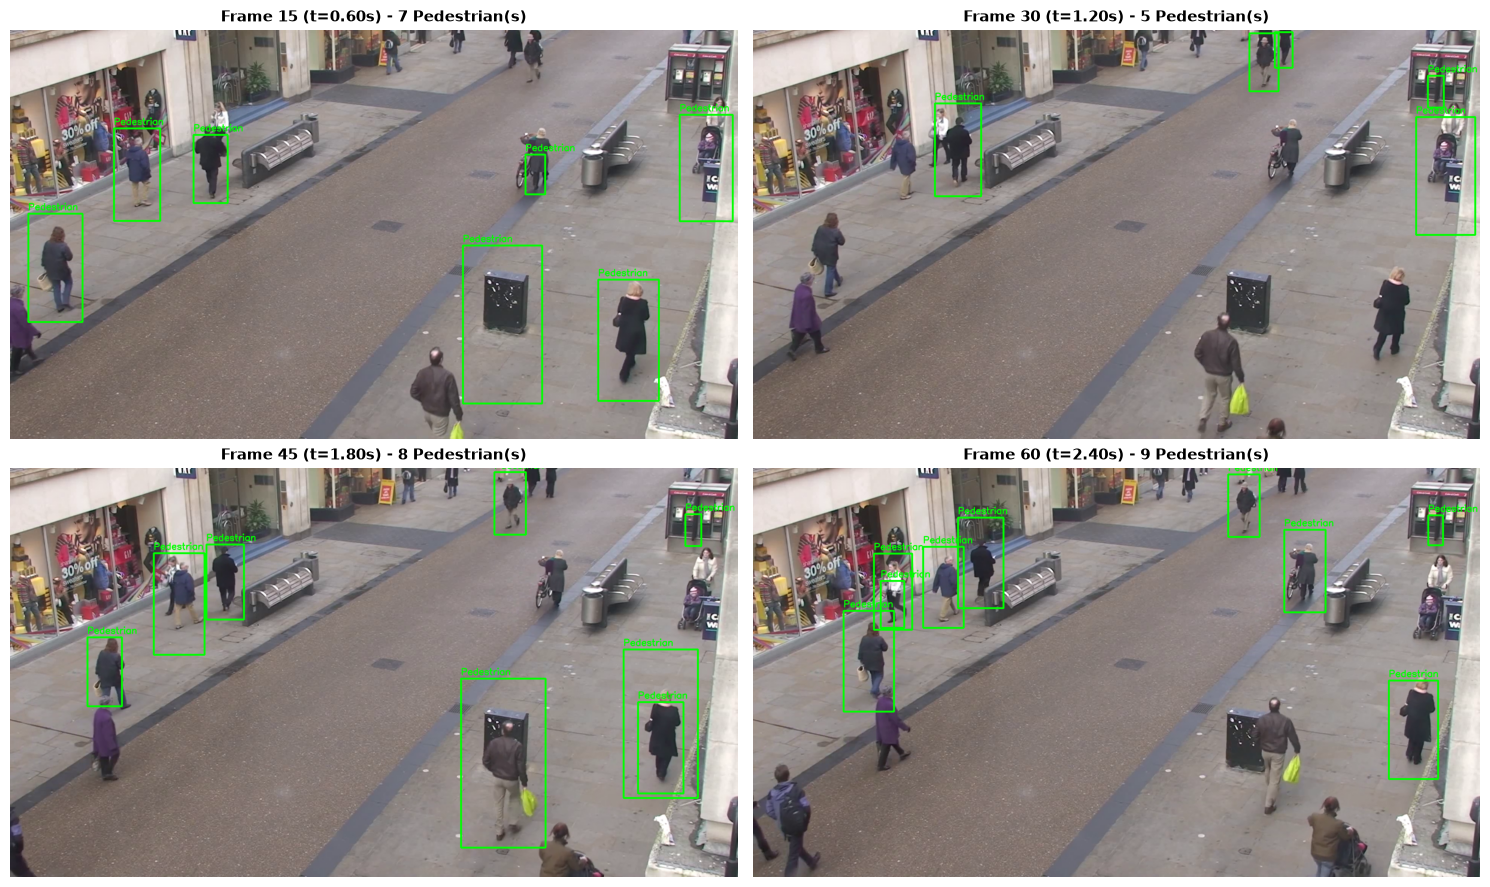

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, res in enumerate(sampled_results):
    axes[i].imshow(res['image'])
    axes[i].set_title(f"Frame {res['frame_idx']} (t={res['timestamp']:.2f}s) - {res['count']} Pedestrian(s)",
                      fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<a id="52-plot-2-cropped-pedestrian-region-of-interest-roi"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Plot 2: Cropped Pedestrian Region of Interest (ROI)</span>

Zooming in on a detected walking pedestrian to inspect full-body silhouette detection up close.

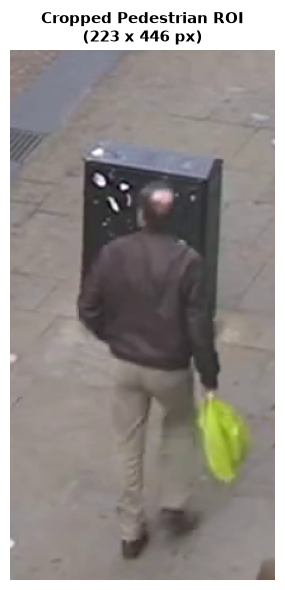

In [6]:
# Extract the prominent pedestrian from Frame 45
frame_45 = sampled_results[2]
if len(frame_45['bodies']) > 0:
    # Select the largest detected body bounding box
    largest_body = max(frame_45['bodies'], key=lambda b: b[2] * b[3])
    x, y, w, h = largest_body
    pedestrian_roi = frame_45['raw_image'][y:y+h, x:x+w]
    
    fig, ax = plt.subplots(figsize=(4, 6))
    ax.imshow(pedestrian_roi)
    ax.set_title(f"Cropped Pedestrian ROI\n({w} x {h} px)", fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

<a id="53-plot-3-pedestrian-count-over-time-flow-analytics"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.3 Plot 3: Pedestrian Count Over Time (Flow Analytics)</span>

Tracking detected pedestrian density across timestamps.

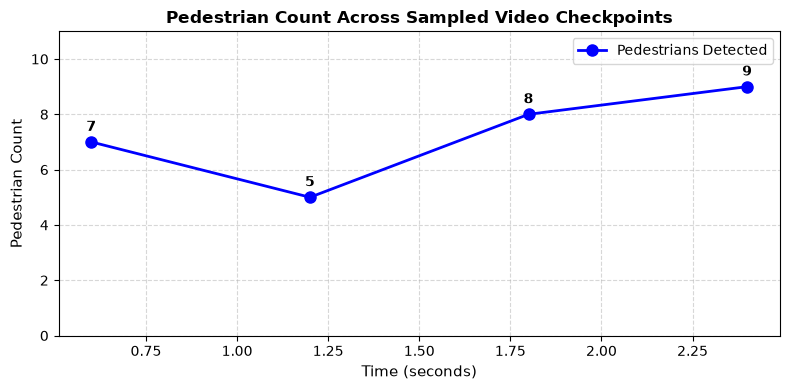

In [7]:
times = [res['timestamp'] for res in sampled_results]
counts = [res['count'] for res in sampled_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, counts, marker='o', color='blue', linewidth=2, markersize=8, label='Pedestrians Detected')

for t, c in zip(times, counts):
    ax.annotate(f'{c}', xy=(t, c), xytext=(0, 8), textcoords="offset points",
                ha='center', fontweight='bold')

ax.set_title("Pedestrian Count Across Sampled Video Checkpoints", fontsize=12, fontweight='bold')
ax.set_xlabel("Time (seconds)", fontsize=11)
ax.set_ylabel("Pedestrian Count", fontsize=11)
ax.set_ylim(0, max(counts) + 2)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

<a id="6-complete-standalone-video-playback-loop"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Complete Standalone Video Playback Loop</span>

Below is the clean, robust implementation of the video loop following the original commented structure:
1. Read the capture frame: `ret, frame = cap.read()`
2. Verify frame read success: `if not ret: break`
3. Convert frame to grayscale: `gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)`
4. Pass frame to classifier: `bodies = body_classifier.detectMultiScale(gray, 1.1, 2)`
5. Draw bounding rectangles: `cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)`
6. Display preview: `cv2.imshow('Pedestrians', frame)`
7. Exit on ESC or 'q': `if cv2.waitKey(25) & 0xFF in [27, ord('q')]: break`
8. Release capture and destroy all windows cleanly: `cap.release()`, `cv2.destroyAllWindows()`

In [ ]:
import os
import cv2
from IPython.display import display, clear_output
from PIL import Image

def play_pedestrian_detection(video_path, max_frames=200):
    """Play pedestrian detection preview in a desktop OpenCV window."""
    if not os.path.exists(video_path):
        print(f"Error: Video file not found at '{video_path}'.")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at '{video_path}'.")
        return

    classifier = globals().get('body_classifier', None)
    if classifier is None or classifier.empty():
        classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_fullbody.xml')

    frame_counter = 0
    print("Starting desktop preview. Press 'q' or 'ESC' on the preview window to stop.")
    
    # Configure resizable window and keep it on top of other windows
    win_name = 'Pedestrian Detection Preview'
    cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win_name, 960, 540)
    try:
        cv2.setWindowProperty(win_name, cv2.WND_PROP_TOPMOST, 1)
    except Exception:
        pass

    while cap.isOpened() and (max_frames is None or frame_counter < max_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame_counter += 1

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bodies = classifier.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=2)

        for (x, y, w, h) in bodies:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)

        cv2.putText(frame, f"Pedestrians: {len(bodies)} | Frame: {frame_counter}",
                    (25, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

        cv2.imshow(win_name, frame)

        # Exit with Esc or 'q' key
        key = cv2.waitKey(25) & 0xFF
        if key == 27 or key == ord('q'):
            print(f"Playback stopped by user at frame {frame_counter}.")
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Capture released and all windows destroyed cleanly.")


def play_pedestrian_detection_inline(video_path, max_frames=60, display_width=720):
    """Play pedestrian detection directly inside the Jupyter Notebook cell (no popup window)."""
    if not os.path.exists(video_path):
        print(f"Error: Video file not found at '{video_path}'.")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at '{video_path}'.")
        return

    classifier = globals().get('body_classifier', None)
    if classifier is None or classifier.empty():
        classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_fullbody.xml')

    frame_counter = 0
    print(f"Streaming inline preview ({max_frames} frames)...")

    while cap.isOpened() and frame_counter < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame_counter += 1

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bodies = classifier.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=2)

        for (x, y, w, h) in bodies:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)

        cv2.putText(frame, f"Pedestrians: {len(bodies)} | Frame: {frame_counter}",
                    (25, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

        # Convert BGR to RGB and resize for inline display
        h, w = frame.shape[:2]
        display_height = int(h * (display_width / w))
        rgb = cv2.cvtColor(cv2.resize(frame, (display_width, display_height)), cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))

    cap.release()
    print(f"Finished inline preview of {frame_counter} frames.")


In [ ]:
# Option A: Live Desktop Window Preview (set on top of VS Code)
play_pedestrian_detection('assets/video/Town_Centre_Surveillance.mp4', max_frames=200)

# Option B: Inline Notebook Preview (uncomment to play directly inside the notebook):
# play_pedestrian_detection_inline('assets/video/Town_Centre_Surveillance.mp4', max_frames=60)


<a id="7-key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Key Takeaways</span>

- **Video Preprocessing**: Always verify `ret` before processing frames to prevent `NoneType` frame exceptions when the stream ends.
- **Silhouette Detection**: Full-body cascades capture vertical aspect ratios typical of standing or walking humans.
- **Resource Cleanup**: Always ensure `cap.release()` and `cv2.destroyAllWindows()` are executed to prevent memory leaks and orphaned GUI threads.
- **Next Step**: In Notebook 05, we apply video object detection to vehicles in traffic surveillance footage.